In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Desktop/Proyecto_Proca/Stability

/Users/armandoroqueestrada/Desktop/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

/Users/armandoroqueestrada/Desktop/Proyecto_Proca/Stability/Modules/SpectralMeth/spectralMet.py:375: SyntaxWarning: invalid escape sequence '\g'
  """


In [4]:
cplot.general()

Mass values: [2.9001212968691057, 2.9001212968691057, 2.9001212968691057]
Eigenvalues of energy: [-0.6845018093788089, -0.6845018034183443, 1.3232144967338977]
17.832759645429718


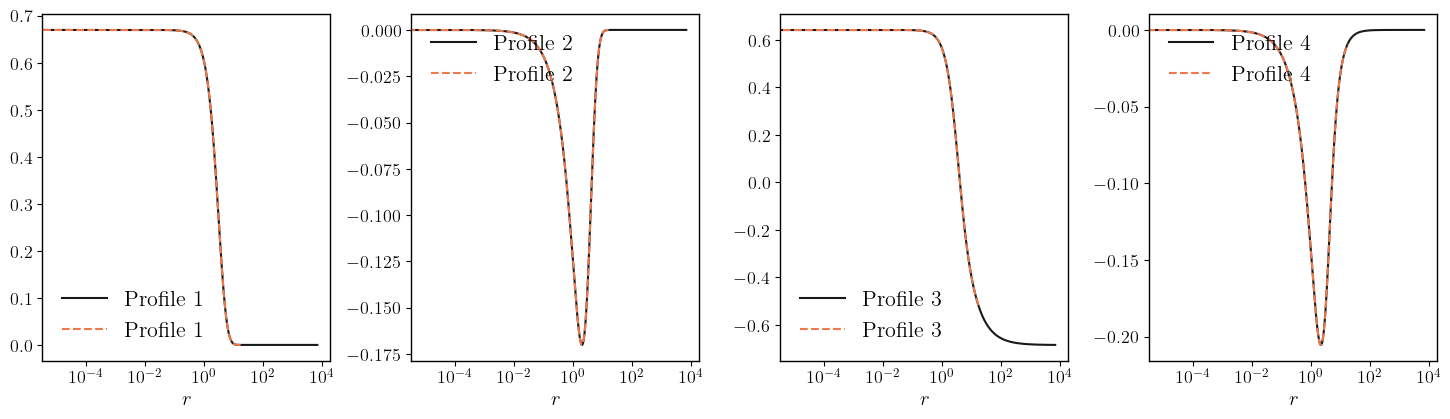

17.832759645429718


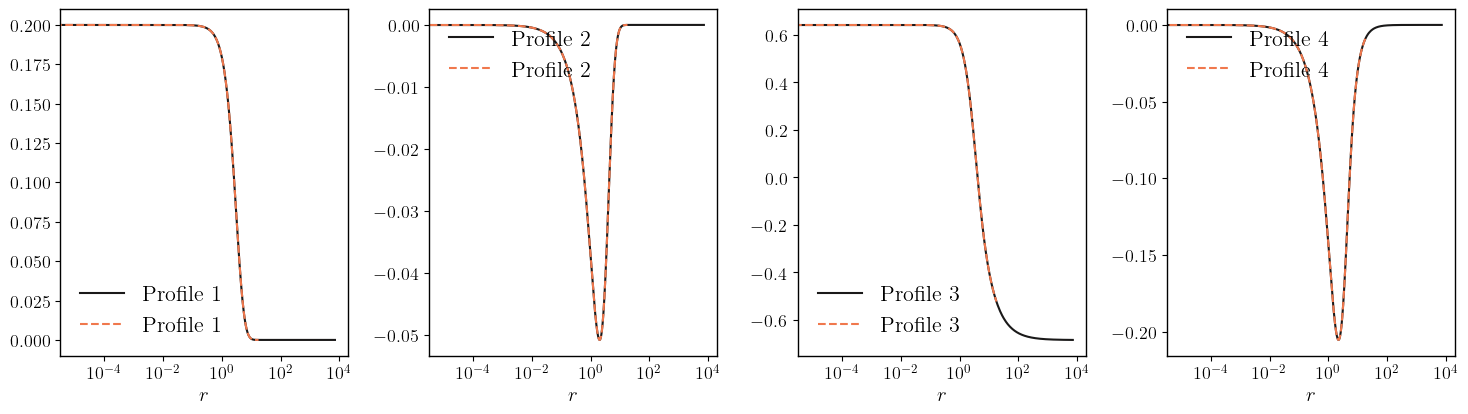

In [5]:
confidata = [[0.6422836938872933, 0.6422836998477579, 2.65, 17.886409958926674, [0.67, 0.2, 0.0], [0, 0, 0], 0]]

# Extendiendo los perfiles
Ext = 7000
Np = int(2e06)

met = 'DOP853'
Rtol = 1e-10
Atol = 1e-12

confidataEx = []
for confi in confidata: # confidata datos
    dataEx = bg.mainExt(confi, mult=True, rmin=0, Nptos=Np, met=met, metExp=1, info=True, indF=-6000,
                    Rtol=Rtol, Atol=Atol, deltaExt=Ext, yscale='linear', xscale='log')  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx)

In [6]:
# Making a null data
zerof = lambda r: 0.*r
rd = confidataEx[0][0][1]
data0 = [0., rd, zerof(rd), zerof(rd), zerof(rd), zerof(rd)]

In [7]:
# Adding a null solution
# confidataEx[0].insert(0, data0)
confidataEx[0].append(data0)  # add a null solution
# confidataEx[0].append(data0)  # add a null solution

### Stability 

In [8]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

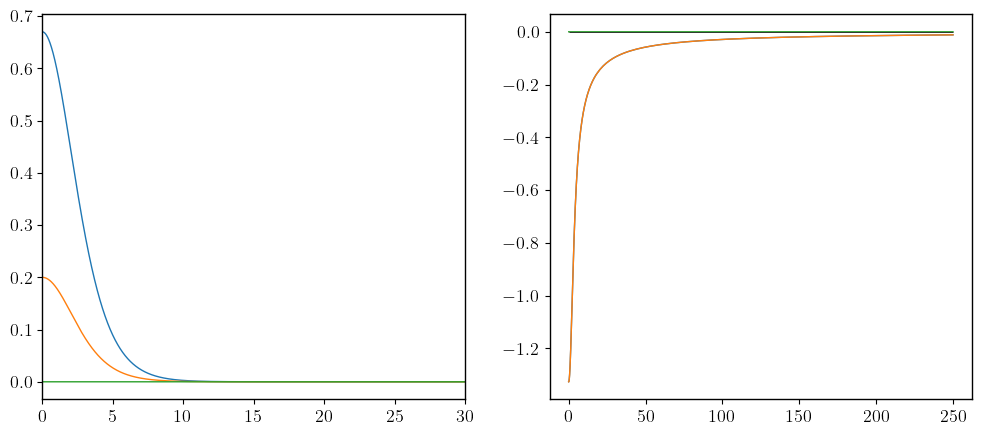

In [14]:
# perf 0
# Debo recuperar los resultados de la polarización linal con n=0

datE = []
datFunc = [[], []]
for s0dat in confidataEx[0]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 0
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) #* 2

Jval = [0, 1, 2, 3]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
# ax[0].set_yscale('log')
plt.show()

lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [15]:
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]


Text(0, 0.5, '$\\lambda_I$')

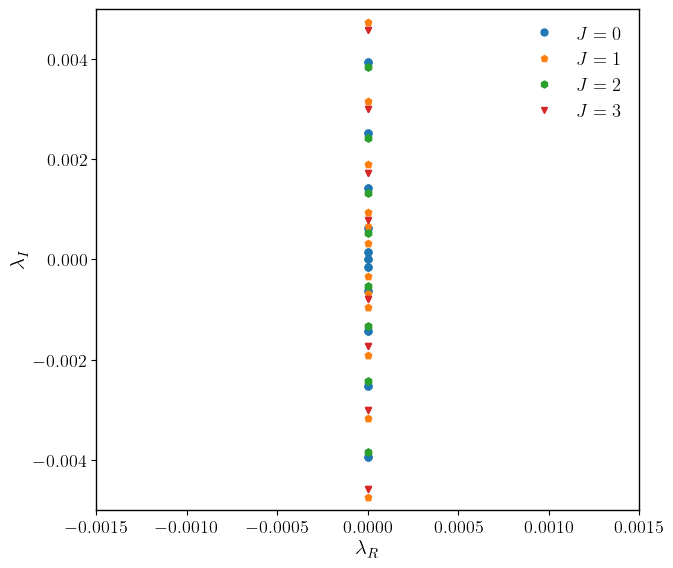

In [ ]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.005, .005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

Jval = 0
[-4.61149448e-07-8.18176681e-10j  4.61149449e-07+8.18096410e-10j]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]


/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_7704/1628800990.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_7704/1628800990.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])


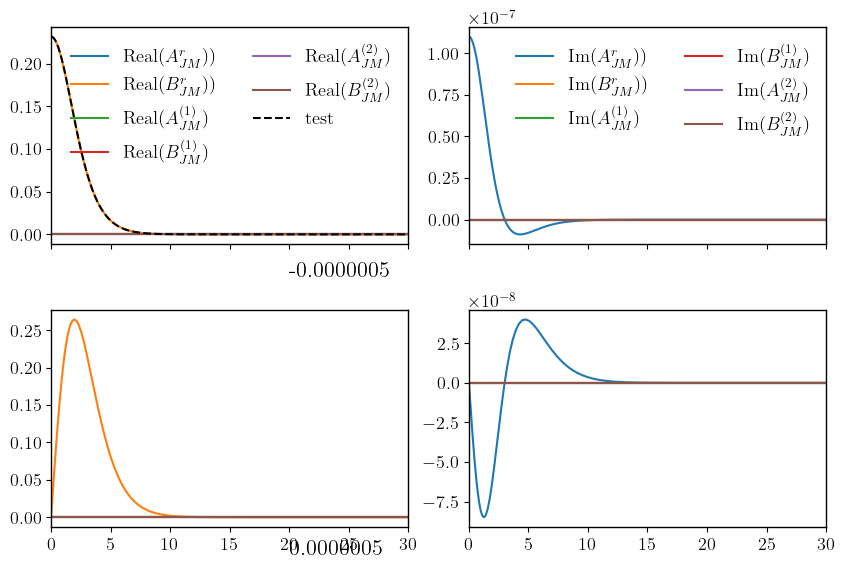

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==0:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Real(%s)'%labels[i])  # notar que /rdis
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Im(%s)'%labels[i])
        
        i = 1
        valc = (np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis)[0]/datFunc[0][0](0)
        ax[0][0].plot(rad, datFunc[0][0](rad)*valc, c='k', ls='--', label='test')
        # ax[0][1].plot(rad, datFunc[0][1](rad)*0.302, c='k', label='test')
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])
        
        ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)
        #ax[0][0].set_ylim(-0.002, 0.002)

In [ ]:
# este modo desaparece y notar como es el modo trivial